In [82]:
#import libraries and data

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

file_path = r"C:\ChurnAnalysis\Data & Resources\Predictiondata.xlsx"

sheet_name = 'View_ChurnData'

data = pd.read_excel(file_path,sheet_name=sheet_name)

print(data.head())

  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   11098-MAD  Female   30     Yes  Madhya Pradesh                    0   
1   11114-PUN    Male   51      No          Punjab                    5   
2   11167-WES  Female   43     Yes     West Bengal                    3   
3   11179-MAH    Male   35      No     Maharashtra                   10   
4   11180-TAM    Male   75     Yes      Tamil Nadu                   12   

   Tenure_in_Months Value_deal Phone_Service Multiple_Lines  ...  \
0                31     Deal 1           Yes             No  ...   
1                 9     Deal 5           Yes             No  ...   
2                28     Deal 1           Yes            Yes  ...   
3                12        NaN           Yes             No  ...   
4                27     Deal 2           Yes             No  ...   

  Paperless_Billing   Payment_Method Monthly_Charge Total_Refunds  \
0                No  Bank Withdrawal      95.099998   6683.399902   
1 

Confusion Matrix:
[[811  39]
 [122 230]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       850
           1       0.86      0.65      0.74       352

    accuracy                           0.87      1202
   macro avg       0.86      0.80      0.83      1202
weighted avg       0.87      0.87      0.86      1202



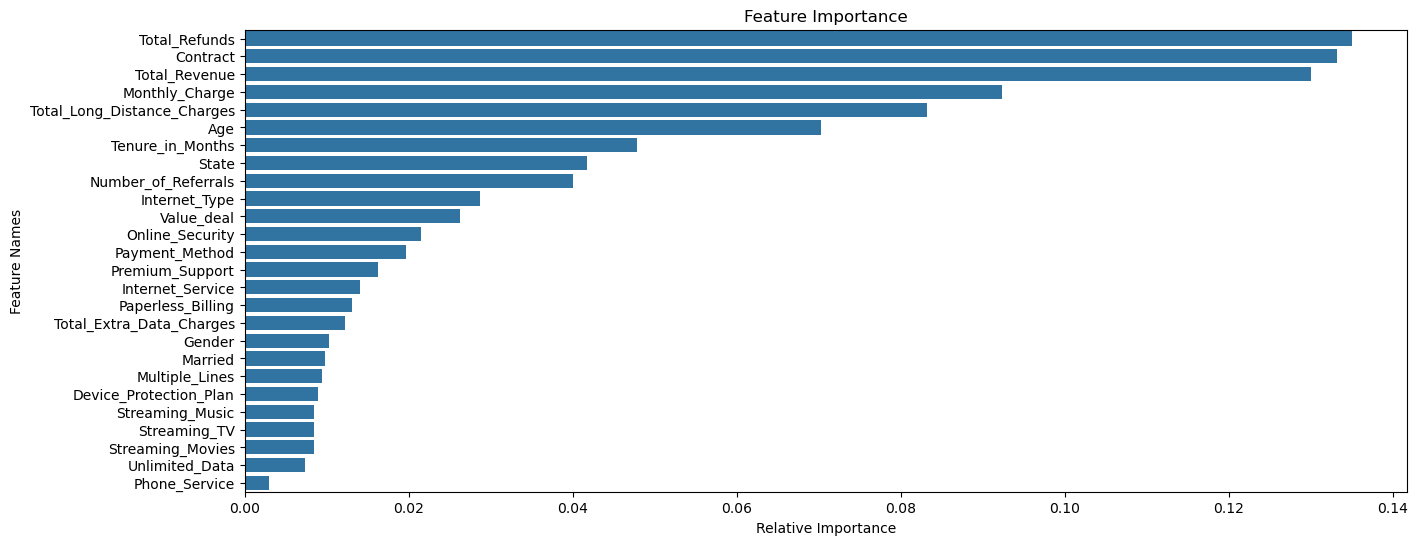

In [83]:
# #Data Processing
# # data = data.drop(['Customer_ID','Churn_Category','Churn_Reason'],axis=1)

# #List of columns to be lable encoded
# columns_to_encode = ['Gender','Married','State','Value_deal','Phone_Service','Multiple_Lines',
#                      'Internet_Service','Internet_Type','Online_Security','Device_Protection_Plan',
#                      'Premium_Support','Streaming_TV','Streaming_Movies','Streaming_Music','Unlimited_Data',
#                      'Contract','Paperless_Billing','Payment_Method']


# label_encoders = {}
# for column in columns_to_encode:
#     label_encoders[column] = LabelEncoder()
#     data[column] = label_encoders[column].fit_transform(data[column])

# #Manually encode the target variable 'Customer_Status'
# data['Customer_Status'] = data['Customer_Status'].map({'Stayed':0,'Churned':1})

# #Split data into features and target
# X=data.drop('Customer_Status',axis=1)
# y = data['Customer_Status']

# #Split data into training and testing sets
# X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# data = data.dropna(subset=['Customer_Status'])

# X = data.drop('Customer_Status', axis=1)
# y = data['Customer_Status']

# # 3. Ab fresh split karo (Aapka exact test_size=0.2 aur random_state=24)
# from sklearn.model_selection import train_test_split
# X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=24)




import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. CLEANING & TARGET ENCODING (Ek sath sab saaf)

# Nan raws remove
data = data.dropna(subset=['Customer_Status'])

# Target Variable ko map karo (Stayed -> 0, Churned -> 1)
if data['Customer_Status'].dtype == 'object':
    data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# drop columns
X = data.drop(['Customer_Status', 'Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1, errors='ignore')
y = data['Customer_Status']



# 2. AUTOMATIC LABEL ENCODING (Bache huye features ke liye)


# Ab X ke andar sirf wahi columns hain jinpar model ko seekhna hai
text_columns = X.select_dtypes(include=['object']).columns.tolist()

label_encoders = {}
for column in text_columns:
    label_encoders[column] = LabelEncoder()
    X[column] = label_encoders[column].fit_transform(X[column].astype(str))



# 3. SPLIT & TRAIN MODEL


# Train-Test Split (test_size=0.2, random_state=24)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=24)

# Random Forest Model Training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)


# 4. OUTPUTS & GRAPH


# Predictions
y_pred = rf_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

# Plot Feature Importance (Ab video wala real graph aayega)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(15,6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()

In [89]:
import pandas as pd

# 1. New Data ko fresh load karo
file_path = r"C:\ChurnAnalysis\Data & Resources\PredictionData.xlsx"
sheet_name = 'View_JoinData'
new_data = pd.read_excel(file_path, sheet_name=sheet_name)

# 2. Original data ka backup rakh lo
original_data = new_data.copy()

# 3. Faltu columns drop kar do
new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1, errors='ignore')


# ==========================================
# 4. 🔥 [EKDUM SIMPLE ENCODING LOOP]
# ==========================================
# Hum har ek text column par baari-baari jayenge
for column in new_data.select_dtypes(include=['object']).columns:
    
    # Pehle us column ki saari khali jagah (NaN) ko 'Unknown' text bana do
    new_data[column] = new_data[column].fillna('Unknown').astype(str)
    
    # Agar ye column hamare trained label_encoders mein moujood hai
    if column in label_encoders:
        
        # Ek ek row ki value ko check karenge ki encoder use jaanta hai ya nahi
        safe_values = []
        for value in new_data[column]:
            if value in label_encoders[column].classes_:
                safe_values.append(value) # Agar word jaana-pehchana hai, toh wahi rehne do
            else:
                # Agar koi naya word ya 'Unknown' aaya, toh use pehle waale jaane-pehchane word se badal do
                first_known_word = label_encoders[column].classes_[0]
                safe_values.append(first_known_word)
        
        # Ab poorane data ko safe data se replace karo aur encode kar do
        new_data[column] = safe_values
        new_data[column] = label_encoders[column].transform(new_data[column])


# ==========================================
# 5. PREDICTION & SAVE (Kuch bhi badla nahi hai yahan)
# ==========================================
# Model se predictions nikaalo
new_predictions = rf_model.predict(new_data)

# Predictions ko original data mein jod do
original_data['Customer_Status_Predicted'] = new_predictions

# Sirf un customers ko nikaalo jo Churn hone waale hain (Predicted == 1)
churned_customers = original_data[original_data['Customer_Status_Predicted'] == 1]

# Result ko save karo (.to_csv sahi spelling ke sath)
output_path = r"C:\ChurnAnalysis\Data & Resources\Churn_Predictions.csv"
churned_customers.to_csv(output_path, index=False)



🎉 Khel khatam bhai! Total 378 rows filter hokar save ho gayi hain.
